# Работа с пропусками через Pandas

<table>

<tr>
<td><img src='https://drive.google.com/uc?id=1BkzQEe97kmEEsJejXCpzp6s-7d7_vDoF'>
</td>
<td>
<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/e/ed/Pandas_logo.svg/1280px-Pandas_logo.svg.png' width=600></td>
</tr>
</table>


# План занятия

- Работа с пропусками через **Pandas**
- Удаление данных с пропусками через **dropna**
- Заполнение NaN на среднее/медиану/моду/константу
- Проставление меток для пропусков через **новые признаки**
- Заполнение пропусков через **группировки**
- **Интерполяция** данных
    - Линейная
    - Предыдущее/Следующее/Ближайшее значение
    - Полиномиальная

# Что нужно знать перед занятием

**1. Теория заполнения пропусков**
https://youtu.be/lg3H1Kd0E4o

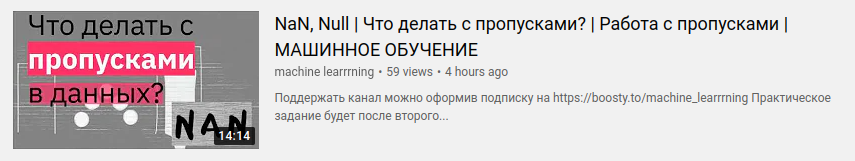

**2. Индексация в pandas**
https://youtube.com/watch?v=gJKN8zyG5c0t=1384

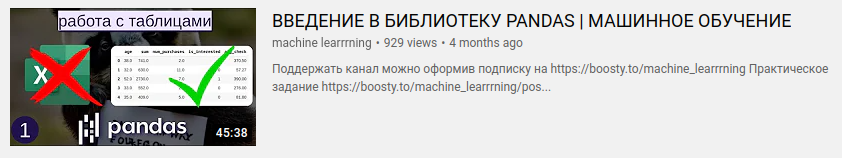

**3. Как создавать новые признаки в pandas**
https://youtu.be/5oEh2kM9vpA

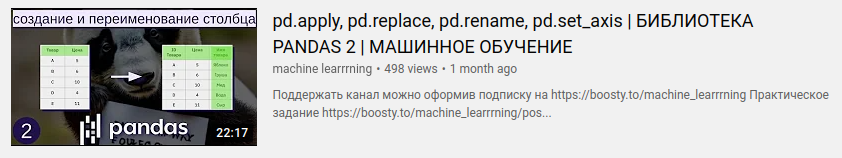

**4. Как группировать данные в pandas**
https://youtu.be/uSW2pstngm0

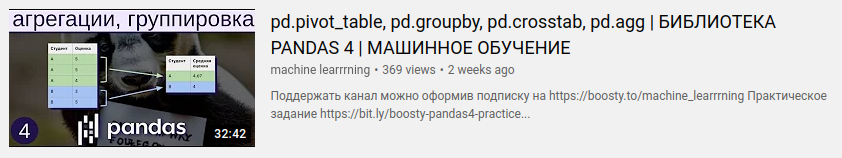


## Поддержка
Платформа boosty https://boosty.to/machine_learrrning



Практика https://bit.ly/boosty-nan-pandas-practice


Доступна
1. по подписке уровня light+ и выше
2. разовая оплата




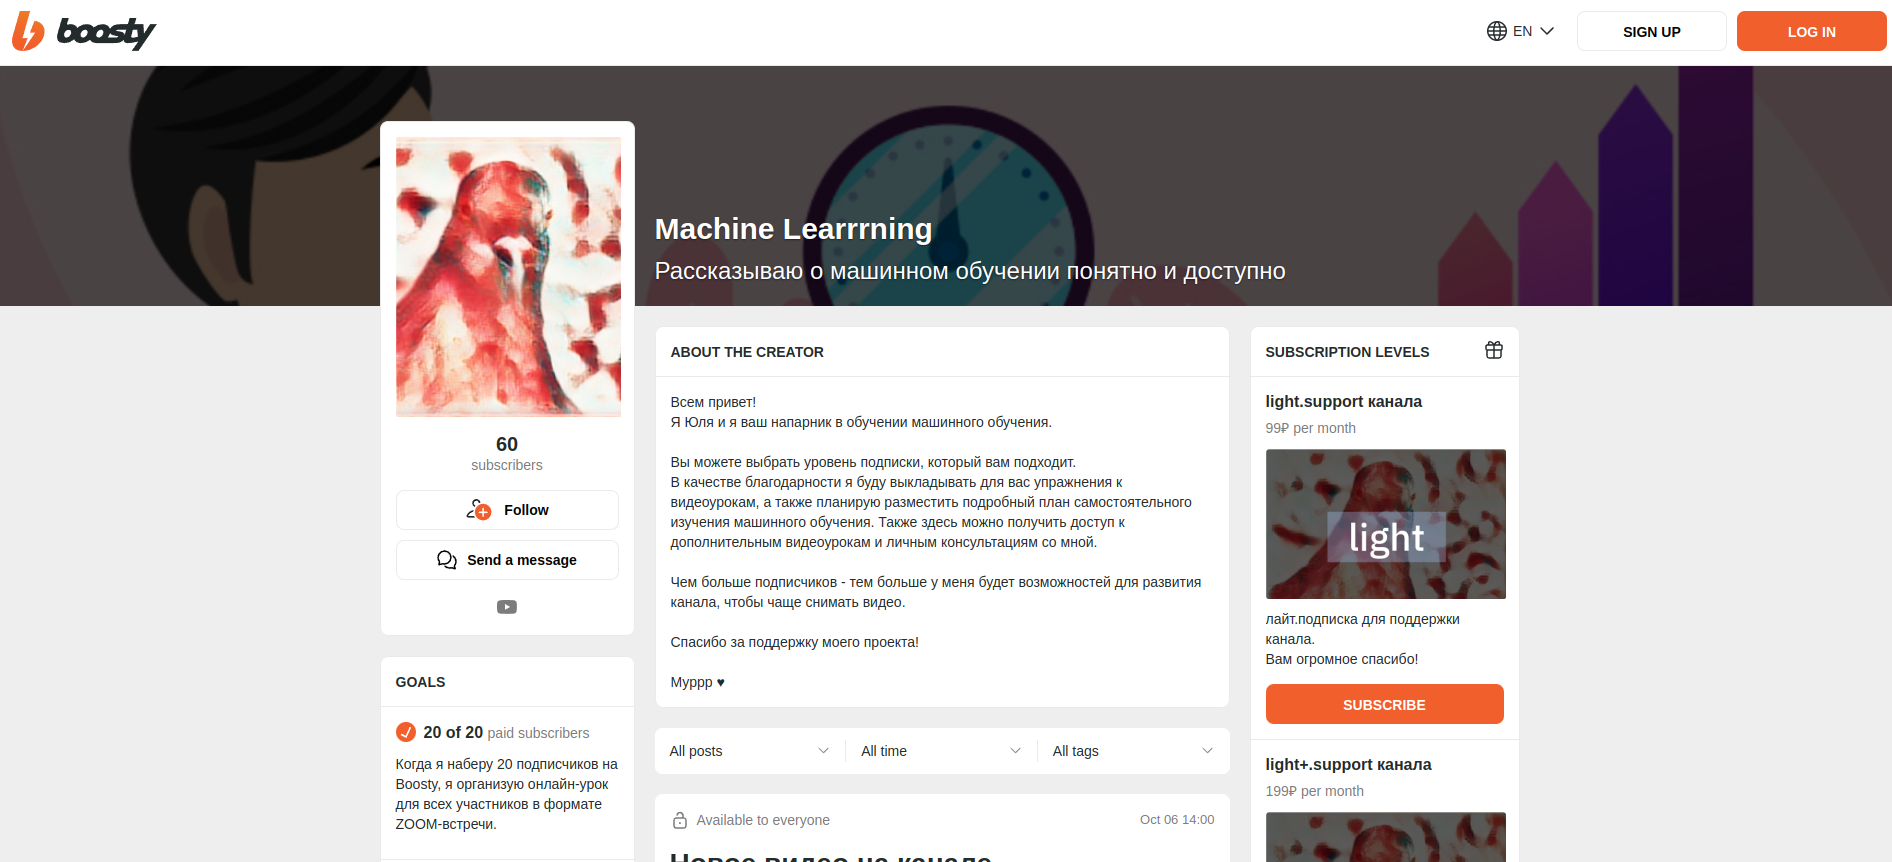


# Handling missing values Powerlifting-database

https://www.kaggle.com/datasets/open-powerlifting/powerlifting-database

In [1]:
import pandas as pd
df = pd.read_csv("../input/powerlifting-database/openpowerlifting.csv", index_col=0)
df.head()

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
MeetID,,,,,,,,,,,,,,,,
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
0,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
0,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
0,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
0,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47


In [2]:
df = df.reset_index(drop=True)
df

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
2,Dawn Bogart,F,Single-ply,42.0,Open Senior,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
3,Dawn Bogart,F,Raw,42.0,Open Senior,58.51,60,NaN,NaN,NaN,95.25,NaN,NaN,95.25,1,108.29
4,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386409,William Barabas,M,Multi-ply,NaN,Elite,113.58,125,NaN,NaN,NaN,NaN,NaN,347.50,347.50,2,202.60
386410,Justin Zottl,M,Multi-ply,NaN,Elite,119.02,125,NaN,NaN,NaN,NaN,NaN,322.50,322.50,3,185.77
386411,Jake Anderson,M,Multi-ply,NaN,Elite,120.29,125,NaN,NaN,NaN,NaN,NaN,367.50,367.50,1,211.17
386412,Jeff Bumanglag,M,Multi-ply,NaN,Elite,126.73,140,NaN,NaN,NaN,NaN,NaN,320.00,320.00,3,181.85


In [3]:
df = df.drop_duplicates(subset=['Name'])
df.head()

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
4,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47
5,Courtney Norris,F,Wraps,28.0,Open Senior,62.41,67.5,-183.7,170.10,NaN,77.11,NaN,145.15,392.36,1,424.40
6,Maureen Clary,F,Raw,60.0,Mst 60-64,67.31,67.5,NaN,124.74,NaN,95.25,NaN,163.29,383.28,1,391.98


In [4]:
df.shape

(136687, 16)

In [7]:
df.isna().sum()

Name                   0
Sex                    0
Equipment              0
Age                82737
Division            6412
BodyweightKg         942
WeightClassKg       1447
Squat4Kg          136217
BestSquatKg        27294
Bench4Kg          135967
BestBenchKg         9683
Deadlift4Kg       135612
BestDeadliftKg     20693
TotalKg             8118
Place                534
Wilks               8568
dtype: int64

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 136687 entries, 0 to 386412
Data columns (total 16 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Name            136687 non-null  object 
 1   Sex             136687 non-null  object 
 2   Equipment       136687 non-null  object 
 3   Age             53950 non-null   float64
 4   Division        130275 non-null  object 
 5   BodyweightKg    135745 non-null  float64
 6   WeightClassKg   135240 non-null  object 
 7   Squat4Kg        470 non-null     float64
 8   BestSquatKg     109393 non-null  float64
 9   Bench4Kg        720 non-null     float64
 10  BestBenchKg     127004 non-null  float64
 11  Deadlift4Kg     1075 non-null    float64
 12  BestDeadliftKg  115994 non-null  float64
 13  TotalKg         128569 non-null  float64
 14  Place           136153 non-null  object 
 15  Wilks           128119 non-null  float64
dtypes: float64(10), object(6)
memory usage: 17.7+ MB


In [9]:
for col in df.columns:
    print(f'{col}: {df[col].isna().sum() / df.shape[0] * 100:.2f}%')

Name: 0.00%
Sex: 0.00%
Equipment: 0.00%
Age: 60.53%
Division: 4.69%
BodyweightKg: 0.69%
WeightClassKg: 1.06%
Squat4Kg: 99.66%
BestSquatKg: 19.97%
Bench4Kg: 99.47%
BestBenchKg: 7.08%
Deadlift4Kg: 99.21%
BestDeadliftKg: 15.14%
TotalKg: 5.94%
Place: 0.39%
Wilks: 6.27%


In [10]:
df[['Age', 'Division']].head()

,Age,Division
0,47.0,Mst 45-49
1,42.0,Mst 40-44
4,18.0,Teen 18-19
5,28.0,Open Senior
6,60.0,Mst 60-64


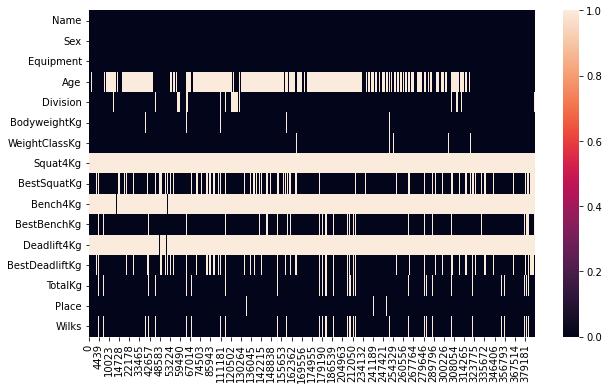

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df.isna().transpose());

# Удалить столбцы/строки с пропусками

In [15]:
cols_to_drop = []

for col in df.columns:
    if df[col].isna().sum() / df.shape[0] > 0.7:
        cols_to_drop.append(col)
        
cols_to_drop

['Squat4Kg', 'Bench4Kg', 'Deadlift4Kg']

In [16]:
df.drop(columns=cols_to_drop)

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05
1,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38
4,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,31.75,90.72,122.47,1,130.47
5,Courtney Norris,F,Wraps,28.0,Open Senior,62.41,67.5,170.10,77.11,145.15,392.36,1,424.40
6,Maureen Clary,F,Raw,60.0,Mst 60-64,67.31,67.5,124.74,95.25,163.29,383.28,1,391.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...
386398,Molly Headly,F,Multi-ply,NaN,Elite,86.73,90,NaN,NaN,220.00,220.00,1,193.20
386402,Bryan Doderdruk,M,Multi-ply,NaN,Elite,97.43,100,NaN,NaN,352.50,352.50,2,216.85
386403,Shawn Schumaker,M,Multi-ply,NaN,Elite,98.79,100,NaN,NaN,365.00,365.00,1,223.24
386406,Matthew Ladewski,M,Multi-ply,NaN,Elite,99.97,100,NaN,NaN,325.00,325.00,4,197.82


## .dropna()

In [20]:
tmp = df.dropna()
tmp.shape

(31, 16)

In [21]:
tmp.isna().sum()

Name              0
Sex               0
Equipment         0
Age               0
Division          0
BodyweightKg      0
WeightClassKg     0
Squat4Kg          0
BestSquatKg       0
Bench4Kg          0
BestBenchKg       0
Deadlift4Kg       0
BestDeadliftKg    0
TotalKg           0
Place             0
Wilks             0
dtype: int64

### axis

In [22]:
tmp = df.dropna(axis=1)  # defaul axis=0
tmp.shape

(136687, 3)

In [23]:
tmp.isna().sum()

Name         0
Sex          0
Equipment    0
dtype: int64

### how

In [24]:
tmp = df.dropna(how='all', axis=0)  # defaul how='any'
tmp.shape

(136687, 16)

In [25]:
tmp = df.dropna(how='all', axis=1)  # defaul how='any'
tmp.shape

(136687, 16)

In [26]:
import numpy as np

tmp = tmp.append(pd.Series([np.nan * 16]), ignore_index=True)
tmp

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks,0
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05,NaN
1,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38,NaN
2,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47,NaN
3,Courtney Norris,F,Wraps,28.0,Open Senior,62.41,67.5,-183.7,170.10,NaN,77.11,NaN,145.15,392.36,1,424.40,NaN
4,Maureen Clary,F,Raw,60.0,Mst 60-64,67.31,67.5,NaN,124.74,NaN,95.25,NaN,163.29,383.28,1,391.98,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136683,Bryan Doderdruk,M,Multi-ply,NaN,Elite,97.43,100,NaN,NaN,NaN,NaN,NaN,352.50,352.50,2,216.85,NaN
136684,Shawn Schumaker,M,Multi-ply,NaN,Elite,98.79,100,NaN,NaN,NaN,NaN,NaN,365.00,365.00,1,223.24,NaN
136685,Matthew Ladewski,M,Multi-ply,NaN,Elite,99.97,100,NaN,NaN,NaN,NaN,NaN,325.00,325.00,4,197.82,NaN
136686,Jeff Bumanglag,M,Multi-ply,NaN,Elite,126.73,140,NaN,NaN,NaN,NaN,NaN,320.00,320.00,3,181.85,NaN


In [27]:
tmp = df.dropna(how='all', axis=0)  # defaul how='any'
tmp

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
4,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47
5,Courtney Norris,F,Wraps,28.0,Open Senior,62.41,67.5,-183.7,170.10,NaN,77.11,NaN,145.15,392.36,1,424.40
6,Maureen Clary,F,Raw,60.0,Mst 60-64,67.31,67.5,NaN,124.74,NaN,95.25,NaN,163.29,383.28,1,391.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386398,Molly Headly,F,Multi-ply,NaN,Elite,86.73,90,NaN,NaN,NaN,NaN,NaN,220.00,220.00,1,193.20
386402,Bryan Doderdruk,M,Multi-ply,NaN,Elite,97.43,100,NaN,NaN,NaN,NaN,NaN,352.50,352.50,2,216.85
386403,Shawn Schumaker,M,Multi-ply,NaN,Elite,98.79,100,NaN,NaN,NaN,NaN,NaN,365.00,365.00,1,223.24
386406,Matthew Ladewski,M,Multi-ply,NaN,Elite,99.97,100,NaN,NaN,NaN,NaN,NaN,325.00,325.00,4,197.82


### thresh

In [28]:
tmp.shape[0] // 2

68343

In [29]:
tmp = df.dropna(thresh=tmp.shape[0] // 2, axis=1)
tmp.shape

(136687, 12)

In [31]:
tmp.columns

Index(['Name', 'Sex', 'Equipment', 'Division', 'BodyweightKg', 'WeightClassKg',
       'BestSquatKg', 'BestBenchKg', 'BestDeadliftKg', 'TotalKg', 'Place',
       'Wilks'],
      dtype='object')

In [30]:
df.columns

Index(['Name', 'Sex', 'Equipment', 'Age', 'Division', 'BodyweightKg',
       'WeightClassKg', 'Squat4Kg', 'BestSquatKg', 'Bench4Kg', 'BestBenchKg',
       'Deadlift4Kg', 'BestDeadliftKg', 'TotalKg', 'Place', 'Wilks'],
      dtype='object')

In [37]:
tmp = df.dropna(thresh=12, axis=0)
tmp.shape

(103925, 16)

In [38]:
tmp.head()

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,Squat4Kg,BestSquatKg,Bench4Kg,BestBenchKg,Deadlift4Kg,BestDeadliftKg,TotalKg,Place,Wilks
0,Angie Belk Terry,F,Wraps,47.0,Mst 45-49,59.60,60,NaN,47.63,NaN,20.41,NaN,70.31,138.35,1,155.05
1,Dawn Bogart,F,Single-ply,42.0,Mst 40-44,58.51,60,NaN,142.88,NaN,95.25,NaN,163.29,401.42,1,456.38
4,Destiny Dula,F,Raw,18.0,Teen 18-19,63.68,67.5,NaN,NaN,NaN,31.75,NaN,90.72,122.47,1,130.47
5,Courtney Norris,F,Wraps,28.0,Open Senior,62.41,67.5,-183.7,170.10,NaN,77.11,NaN,145.15,392.36,1,424.40
6,Maureen Clary,F,Raw,60.0,Mst 60-64,67.31,67.5,NaN,124.74,NaN,95.25,NaN,163.29,383.28,1,391.98


### subset

In [41]:
tmp = df.dropna(subset=['Age'], axis=0)
tmp.shape

(53950, 16)

In [42]:
tmp.isna().sum()

Name                  0
Sex                   0
Equipment             0
Age                   0
Division           3561
BodyweightKg         76
WeightClassKg       793
Squat4Kg          53608
BestSquatKg       11485
Bench4Kg          53454
BestBenchKg        3929
Deadlift4Kg       53211
BestDeadliftKg     7990
TotalKg            2972
Place                35
Wilks              3024
dtype: int64

### inplace

In [43]:
df.shape[0] // 3

45562

In [44]:
df.dropna(thresh=df.shape[0] // 3, axis=1, inplace=True)
df.shape

/opt/conda/lib/python3.7/site-packages/pandas/util/_decorators.py:311: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return func(*args, **kwargs)


(136687, 13)

In [45]:
df = df.dropna(thresh=10, axis=0)
df.shape

(129539, 13)

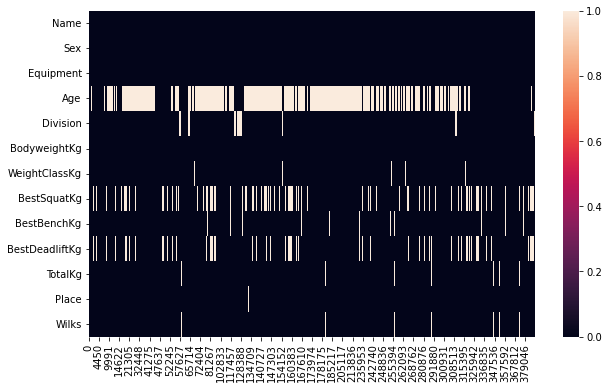

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isna().transpose());

# Заполнение пропусков

## Среднее, медиана, мода

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 129539 entries, 0 to 386412
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Name            129539 non-null  object 
 1   Sex             129539 non-null  object 
 2   Equipment       129539 non-null  object 
 3   Age             52327 non-null   float64
 4   Division        123850 non-null  object 
 5   BodyweightKg    129361 non-null  float64
 6   WeightClassKg   128750 non-null  object 
 7   BestSquatKg     106818 non-null  float64
 8   BestBenchKg     125228 non-null  float64
 9   BestDeadliftKg  114695 non-null  float64
 10  TotalKg         127981 non-null  float64
 11  Place           129162 non-null  object 
 12  Wilks           127803 non-null  float64
dtypes: float64(7), object(6)
memory usage: 17.9+ MB


### Признак количественный

In [48]:
df['BodyweightKg'].mean()

85.31247021126923

In [49]:
df['BodyweightKg'].median()

82.1

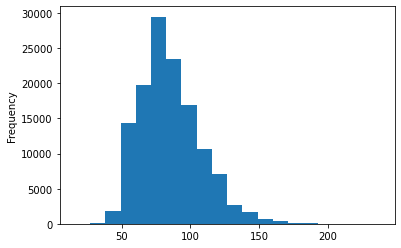

In [50]:
df['BodyweightKg'].plot(kind='hist', bins=20);

In [51]:
df['BodyweightKg'].fillna(df['BodyweightKg'].median())

0          59.60
1          58.51
4          63.68
5          62.41
6          67.31
           ...  
386398     86.73
386402     97.43
386403     98.79
386406     99.97
386412    126.73
Name: BodyweightKg, Length: 129539, dtype: float64

In [52]:
df['BodyweightKg'].isna().sum()

178

In [53]:
df['BodyweightKg'] = df['BodyweightKg'].fillna(df['BodyweightKg'].median())
# df['BodyweightKg'].fillna(df['BodyweightKg'].median(), inplace=True)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [54]:
df['BodyweightKg'].isna().sum()

0

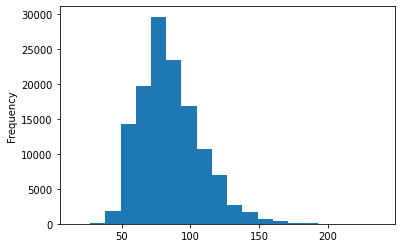

In [55]:
df['BodyweightKg'].plot(kind='hist', bins=20);

### Признак качественный

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 129539 entries, 0 to 386412
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Name            129539 non-null  object 
 1   Sex             129539 non-null  object 
 2   Equipment       129539 non-null  object 
 3   Age             52327 non-null   float64
 4   Division        123850 non-null  object 
 5   BodyweightKg    129539 non-null  float64
 6   WeightClassKg   128750 non-null  object 
 7   BestSquatKg     106818 non-null  float64
 8   BestBenchKg     125228 non-null  float64
 9   BestDeadliftKg  114695 non-null  float64
 10  TotalKg         127981 non-null  float64
 11  Place           129162 non-null  object 
 12  Wilks           127803 non-null  float64
dtypes: float64(7), object(6)
memory usage: 17.9+ MB


In [57]:
df['Division'].value_counts()

Open                 21239
Boys                 14267
R-O                  10280
Amateur Open          4964
R-JR                  3264
                     ...  
Master (65-69)           1
Women Juniors            1
Men Teens 18-19          1
Women Teens 18-19        1
Pro Heavy                1
Name: Division, Length: 3121, dtype: int64

In [58]:
df['Division'] = df['Division'].str.lower()

df['Division'].value_counts()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


open            21449
boys            14267
r-o             10280
amateur open     5001
r-jr             3264
                ...  
aretroopen          1
n                   1
dlint               1
retrom1             1
pro heavy           1
Name: Division, Length: 3013, dtype: int64

In [61]:
df['Division'].mode()

0    open
dtype: object

In [62]:
df['Division'] = df['Division'].fillna(df['Division'].mode())
df['Division'].isna().sum()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


5689

In [63]:
division_mode = df['Division'].mode().iloc[0]
division_mode

'open'

In [64]:
df['Division'] = df['Division'].fillna(division_mode)
df['Division'].isna().sum()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


0

## Indicator

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 129539 entries, 0 to 386412
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Name            129539 non-null  object 
 1   Sex             129539 non-null  object 
 2   Equipment       129539 non-null  object 
 3   Age             52327 non-null   float64
 4   Division        129539 non-null  object 
 5   BodyweightKg    129539 non-null  float64
 6   WeightClassKg   128750 non-null  object 
 7   BestSquatKg     106818 non-null  float64
 8   BestBenchKg     125228 non-null  float64
 9   BestDeadliftKg  114695 non-null  float64
 10  TotalKg         127981 non-null  float64
 11  Place           129162 non-null  object 
 12  Wilks           127803 non-null  float64
dtypes: float64(7), object(6)
memory usage: 17.9+ MB


In [66]:
df['Place'].value_counts()

1     64367
2     20958
3     11279
4      7247
5      5074
      ...  
69        1
66        1
76        1
68        1
63        1
Name: Place, Length: 79, dtype: int64

In [67]:
df['Place_nan'] = 0
df.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
0,Angie Belk Terry,F,Wraps,47.0,mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05,0
1,Dawn Bogart,F,Single-ply,42.0,mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38,0
4,Destiny Dula,F,Raw,18.0,teen 18-19,63.68,67.5,NaN,31.75,90.72,122.47,1,130.47,0
5,Courtney Norris,F,Wraps,28.0,open senior,62.41,67.5,170.10,77.11,145.15,392.36,1,424.40,0
6,Maureen Clary,F,Raw,60.0,mst 60-64,67.31,67.5,124.74,95.25,163.29,383.28,1,391.98,0


In [68]:
df.loc[df['Place'].isna(), 'Place_nan'] = 1
df[df['Place'].isna()].head()

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1817: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value, pi)


,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
3517,Pam McKeage,F,Raw,32.0,open,68.9,NaN,NaN,47.5,95.0,142.5,NaN,143.34,1
4927,Chandan McCall,M,Raw,17.0,teen,116.8,NaN,215.0,140.0,220.0,575.0,NaN,332.76,1
4928,Paolo DeMarco,M,Raw,19.0,teen,77.1,NaN,150.0,115.0,165.0,430.0,NaN,300.68,1
4929,Keller Nicolai,M,Raw,16.0,teen,102.5,NaN,157.5,105.0,187.5,450.0,NaN,271.26,1
4934,Lisa O'Kane,F,Raw,29.0,open,65.3,NaN,115.0,70.0,125.0,310.0,NaN,324.12,1


In [69]:
df['Place_nan'].value_counts()

0    129162
1       377
Name: Place_nan, dtype: int64

In [70]:
df['Place'].isna().sum()

377

In [71]:
df['Place'].fillna(0, inplace=True)
df['Place'].isna().sum()

/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


0

In [72]:
df[df['Place_nan'] == 1].head()

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
3517,Pam McKeage,F,Raw,32.0,open,68.9,NaN,NaN,47.5,95.0,142.5,0,143.34,1
4927,Chandan McCall,M,Raw,17.0,teen,116.8,NaN,215.0,140.0,220.0,575.0,0,332.76,1
4928,Paolo DeMarco,M,Raw,19.0,teen,77.1,NaN,150.0,115.0,165.0,430.0,0,300.68,1
4929,Keller Nicolai,M,Raw,16.0,teen,102.5,NaN,157.5,105.0,187.5,450.0,0,271.26,1
4934,Lisa O'Kane,F,Raw,29.0,open,65.3,NaN,115.0,70.0,125.0,310.0,0,324.12,1


## Неизвестность 

In [73]:
df['WeightClassKg'].value_counts()

90       12549
82.5     11854
75       11846
100      11567
67.5      9473
110       8646
125       6597
93        5612
83        5383
60        4781
105       4124
74        3818
72        3322
52        3220
56        3138
63        2707
120       2263
84        2151
140       2004
57        1796
66        1725
84+       1695
90+       1454
120+      1374
140+      1367
125+      1337
59         800
48         603
47         402
44         316
117.5      289
53         189
43          68
110+        65
40          34
75+         33
35          33
70          20
80          19
30          18
145         16
100+        13
95          10
83+          6
70+          5
67.5+        3
60+          3
39           2
Name: WeightClassKg, dtype: int64

In [74]:
df['WeightClassKg'].fillna('Unknown', inplace=True)

df.isna().sum()

/opt/conda/lib/python3.7/site-packages/pandas/core/generic.py:6392: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return self._update_inplace(result)


Name                  0
Sex                   0
Equipment             0
Age               77212
Division              0
BodyweightKg          0
WeightClassKg         0
BestSquatKg       22721
BestBenchKg        4311
BestDeadliftKg    14844
TotalKg            1558
Place                 0
Wilks              1736
Place_nan             0
dtype: int64

## Более умное заполнение средними/медианами/модами

In [75]:
df['Age'].isna().sum()

77212

In [76]:
df.groupby('Division')['Age'].median()

Division
-100kg      29.0
11-12r      12.0
12*13       12.5
12-13       13.0
13-15       14.0
            ... 
yth          NaN
м1 40-49     NaN
м2 50-59     NaN
м3 60-69     NaN
м4 70-79     NaN
Name: Age, Length: 3013, dtype: float64

In [77]:
df[df['Division'] == 'м1 40-49']

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
383175,Vladimir Gavrish,M,Wraps,NaN,м1 40-49,80.9,82.5,185.0,125.0,210.0,520.0,1,352.53,0
383191,Vyacheslav Bondarev,M,Wraps,NaN,м1 40-49,88.8,90,195.0,165.0,225.0,585.0,1,376.05,0
383213,Konstantin Udalov,M,Wraps,NaN,м1 40-49,93.0,100,230.0,160.0,240.0,630.0,1,395.76,0
383214,Oleg Usatenko,M,Wraps,NaN,м1 40-49,99.5,100,220.0,150.0,220.0,590.0,2,359.79,0
383235,Anatoliy Andreev,M,Wraps,NaN,м1 40-49,122.3,125,190.0,140.0,200.0,530.0,2,303.41,0
383279,Nurzhan Zhalpakov,M,Raw,NaN,м1 40-49,66.3,67.5,NaN,115.0,NaN,115.0,1,89.96,0
383297,Anatoliy Dorokhov,M,Raw,NaN,м1 40-49,73.5,75,NaN,150.0,NaN,150.0,1,108.42,0
383325,Vitaliy Kravtsov,M,Raw,NaN,м1 40-49,81.0,82.5,NaN,155.0,NaN,155.0,2,105.00,0
383326,Vladimir Ashchepkov,M,Raw,NaN,м1 40-49,80.0,82.5,NaN,140.0,NaN,140.0,3,95.58,0
383369,Igor Maksimov,M,Raw,NaN,м1 40-49,99.4,100,NaN,135.0,NaN,135.0,1,82.36,0


In [78]:
age_by_division = df.groupby('Division')['Age'].transform('median')
age_by_division

0         47.0
1         42.0
4         19.0
5         28.0
6         60.5
          ... 
386398     NaN
386402     NaN
386403     NaN
386406     NaN
386412     NaN
Name: Age, Length: 129539, dtype: float64

In [79]:
df[df['Age'].isna()]

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
834,Gloria Moses,F,Raw,NaN,open,73.00,75,145.0,80.0,165.0,390.0,1,377.21,0
861,Martin Drake,M,Raw,NaN,lm 65-69,74.93,75,NaN,130.0,NaN,130.0,1,92.69,0
1096,Lucas Johnson,M,Raw,NaN,r open,100.00,100,227.5,145.0,320.0,692.5,1,421.45,0
1117,W. Jackson,M,Single-ply,NaN,open,52.00,52,142.5,80.0,195.0,417.5,1,409.68,0
1118,T. Carver,M,Single-ply,NaN,open,52.00,52,137.5,77.5,185.0,400.0,2,392.51,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
386398,Molly Headly,F,Multi-ply,NaN,elite,86.73,90,NaN,NaN,220.0,220.0,1,193.20,0
386402,Bryan Doderdruk,M,Multi-ply,NaN,elite,97.43,100,NaN,NaN,352.5,352.5,2,216.85,0
386403,Shawn Schumaker,M,Multi-ply,NaN,elite,98.79,100,NaN,NaN,365.0,365.0,1,223.24,0
386406,Matthew Ladewski,M,Multi-ply,NaN,elite,99.97,100,NaN,NaN,325.0,325.0,4,197.82,0


In [80]:
df[df['Division'] == 'lm 65-69']

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
861,Martin Drake,M,Raw,NaN,lm 65-69,74.93,75,NaN,130.0,NaN,130.0,1,92.69,0
888,Charlie Jones,M,Raw,67.0,lm 65-69,107.50,110,NaN,145.0,NaN,145.0,1,85.96,0
908,Robert Bienvienu,M,Single-ply,67.0,lm 65-69,82.19,82.5,NaN,82.5,NaN,82.5,1,55.39,0


In [81]:
idx = 861

In [82]:
age_by_division.loc[idx]

67.0

In [83]:
df['Age'] = df['Age'].fillna(age_by_division)
df.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
0,Angie Belk Terry,F,Wraps,47.0,mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05,0
1,Dawn Bogart,F,Single-ply,42.0,mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38,0
4,Destiny Dula,F,Raw,18.0,teen 18-19,63.68,67.5,NaN,31.75,90.72,122.47,1,130.47,0
5,Courtney Norris,F,Wraps,28.0,open senior,62.41,67.5,170.10,77.11,145.15,392.36,1,424.40,0
6,Maureen Clary,F,Raw,60.0,mst 60-64,67.31,67.5,124.74,95.25,163.29,383.28,1,391.98,0


In [84]:
df.loc[[idx]]

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan
861,Martin Drake,M,Raw,67.0,lm 65-69,74.93,75,NaN,130.0,NaN,130.0,1,92.69,0


In [85]:
df['Age'].isna().sum()

23607

In [86]:
division_missing_age = df[df['Age'].isna()]['Division'].value_counts()
division_missing_age

boys               14267
teen 14-18          1082
sub-junior          1009
varsity              599
nov                  585
                   ...  
amateur subm-33        1
pro sub-m-33           1
pro subm-33            1
pro j-23               1
pro heavy              1
Name: Division, Length: 897, dtype: int64

In [87]:
division_missing_age_df = division_missing_age.index.str.extract('(\d\d)-(\d\d)|(\d\d)')
division_missing_age_df

,0,1,2
0,NaN,NaN,NaN
1,14,18,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
...,...,...,...
892,NaN,NaN,33
893,NaN,NaN,33
894,NaN,NaN,33
895,NaN,NaN,23


In [88]:
division_missing_age_df['Division'] = division_missing_age.index
division_missing_age_df

,0,1,2,Division
0,NaN,NaN,NaN,boys
1,14,18,NaN,teen 14-18
2,NaN,NaN,NaN,sub-junior
3,NaN,NaN,NaN,varsity
4,NaN,NaN,NaN,nov
...,...,...,...,...
892,NaN,NaN,33,amateur subm-33
893,NaN,NaN,33,pro sub-m-33
894,NaN,NaN,33,pro subm-33
895,NaN,NaN,23,pro j-23


In [89]:
def count_mean(x):
    if not x[0] is np.nan:
        return (int(x[0]) + int(x[1])) / 2
    elif not x[2] is np.nan:
        return x[2]
    else:
        return np.nan
    
division_missing_age_df['mean'] = division_missing_age_df.apply(count_mean, axis=1)
division_missing_age_df

,0,1,2,Division,mean
0,NaN,NaN,NaN,boys,NaN
1,14,18,NaN,teen 14-18,16.0
2,NaN,NaN,NaN,sub-junior,NaN
3,NaN,NaN,NaN,varsity,NaN
4,NaN,NaN,NaN,nov,NaN
...,...,...,...,...,...
892,NaN,NaN,33,amateur subm-33,33
893,NaN,NaN,33,pro sub-m-33,33
894,NaN,NaN,33,pro subm-33,33
895,NaN,NaN,23,pro j-23,23


In [90]:
division_missing_age_df['mean'].isna().sum()

492

In [91]:
df = df.merge(division_missing_age_df[['Division', 'mean']], on='Division', how='left')
df.head()

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan,mean
0,Angie Belk Terry,F,Wraps,47.0,mst 45-49,59.60,60,47.63,20.41,70.31,138.35,1,155.05,0,NaN
1,Dawn Bogart,F,Single-ply,42.0,mst 40-44,58.51,60,142.88,95.25,163.29,401.42,1,456.38,0,NaN
2,Destiny Dula,F,Raw,18.0,teen 18-19,63.68,67.5,NaN,31.75,90.72,122.47,1,130.47,0,NaN
3,Courtney Norris,F,Wraps,28.0,open senior,62.41,67.5,170.10,77.11,145.15,392.36,1,424.40,0,NaN
4,Maureen Clary,F,Raw,60.0,mst 60-64,67.31,67.5,124.74,95.25,163.29,383.28,1,391.98,0,NaN


In [92]:
mean_age_by_division = df.groupby('Division')['mean'].transform('mean')
mean_age_by_division

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
129534   NaN
129535   NaN
129536   NaN
129537   NaN
129538   NaN
Name: mean, Length: 129539, dtype: float64

In [93]:
df[df['Division'] == 'teen 14-18']

,Name,Sex,Equipment,Age,Division,BodyweightKg,WeightClassKg,BestSquatKg,BestBenchKg,BestDeadliftKg,TotalKg,Place,Wilks,Place_nan,mean
34821,Paul André Solberg,M,Single-ply,NaN,teen 14-18,72.0,75,NaN,90.0,NaN,90.0,1,66.03,0,16.0
34822,Morten Werner Olsen,M,Single-ply,NaN,teen 14-18,94.9,100,NaN,117.5,NaN,117.5,1,73.12,0,16.0
34840,Joakim Jensen,M,Single-ply,NaN,teen 14-18,72.1,75,125.0,75.0,170.0,370.0,1,271.19,0,16.0
34845,Kristian Helland,M,Single-ply,NaN,teen 14-18,79.9,82.5,135.0,122.5,155.0,412.5,1,281.84,0,16.0
34854,Marius Vetaas,M,Single-ply,NaN,teen 14-18,86.2,90,130.0,85.0,140.0,355.0,1,231.88,0,16.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38897,Ingvild Roksvaag,F,Single-ply,NaN,teen 14-18,54.8,56,45.0,30.0,90.0,165.0,1,197.46,0,16.0
38898,Grethe Lund,F,Single-ply,NaN,teen 14-18,67.3,67.5,90.0,37.5,100.0,227.5,1,232.69,0,16.0
38902,Isabel A. Haugstvedt,F,Single-ply,NaN,teen 14-18,61.6,67.5,70.0,42.5,70.0,182.5,1,199.38,0,16.0
38903,Lucie H. Larsen,F,Single-ply,NaN,teen 14-18,61.2,67.5,72.5,30.0,77.5,180.0,2,197.64,0,16.0


In [94]:
mean_age_by_division.loc[34821]

16.0

In [95]:
df['Age'] = df['Age'].fillna(mean_age_by_division)
df['Age'].isna().sum()

20955

In [96]:
division_missing_age = df[df['Age'].isna()]['Division'].value_counts()
division_missing_age

boys                       14267
sub-junior                  1009
varsity                      599
nov                          585
int                          249
                           ...  
amateur junior/military        1
amateur sub-master             1
pro military                   1
pro open junior                1
pro heavy                      1
Name: Division, Length: 492, dtype: int64

In [97]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 129539 entries, 0 to 129538
Data columns (total 15 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Name            129539 non-null  object 
 1   Sex             129539 non-null  object 
 2   Equipment       129539 non-null  object 
 3   Age             129539 non-null  float64
 4   Division        129539 non-null  object 
 5   BodyweightKg    129539 non-null  float64
 6   WeightClassKg   129539 non-null  object 
 7   BestSquatKg     106818 non-null  float64
 8   BestBenchKg     125228 non-null  float64
 9   BestDeadliftKg  114695 non-null  float64
 10  TotalKg         127981 non-null  float64
 11  Place           129539 non-null  object 
 12  Wilks           127803 non-null  float64
 13  Place_nan       129539 non-null  int64  
 14  mean            2652 non-null    object 
dtypes: float64(7), int64(1), object(7)
memory usage: 19.8+ MB


In [98]:
df.drop(columns='mean', inplace=True)

## Интерполировать

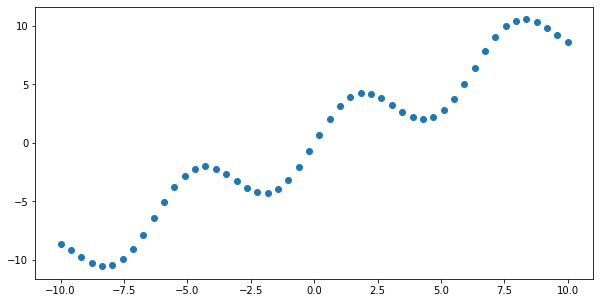

In [99]:
x = np.linspace(-10, 10, num=50)
y = 2.5 * np.sin(x) + x

plt.figure(figsize=(10, 5))
plt.scatter(x, y);

In [100]:
df = pd.DataFrame({'x': x, 'true_y': y})
df

,x,true_y
0,-10.000000,-8.639947
1,-9.591837,-9.176130
2,-9.183673,-9.780612
3,-8.775510,-10.287018
4,-8.367347,-10.545089
5,-7.959184,-10.445362
6,-7.551020,-9.937163
7,-7.142857,-9.036928
8,-6.734694,-7.825502
9,-6.326531,-6.434860


In [101]:
np.random.seed(9)

df['y'] = df['true_y']
df.loc[np.random.randint(0, 50, 10), 'y'] = np.nan
df.head()

,x,true_y,y
0,-10.000000,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN
2,-9.183673,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089


In [102]:
nan_x = df[df['y'].isna()]['x']
nan_y = df[df['y'].isna()]['true_y']

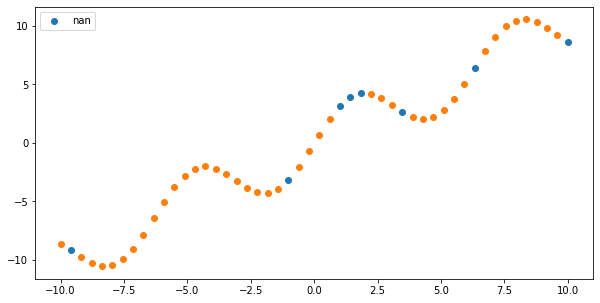

In [103]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y'])
plt.legend();

### linear interpolation

In [104]:
df['y_lin'] = df['y'].interpolate()
df.head()

,x,true_y,y,y_lin
0,-10.000000,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279
2,-9.183673,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089


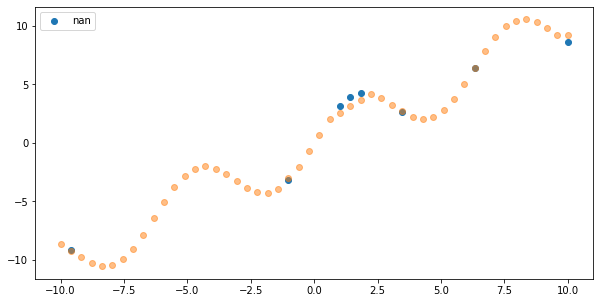

In [105]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_lin'], alpha=0.5)
plt.legend();

In [106]:
np.mean(np.abs(df['true_y'] - df['y_lin']))

0.05506338361659317

### padding

In [107]:
df['y_pad'] = df['y'].interpolate(method='pad', limit=2)
df.head()

,x,true_y,y,y_lin,y_pad
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089


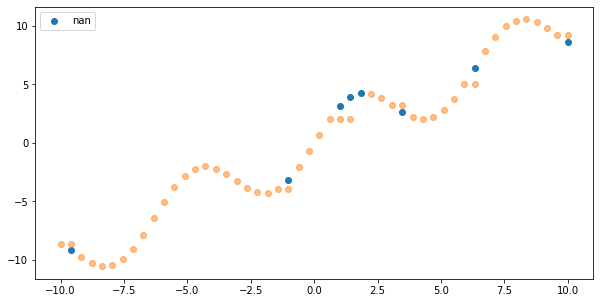

In [108]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_pad'], alpha=0.5)
plt.legend();

In [109]:
np.mean(np.abs(df['true_y'] - df['y_pad']))

0.1385076673888301

In [110]:
df['y_pad_fillna'] = df['y']
df['y_pad_fillna'] = df['y_pad_fillna'].fillna(method="pad")
df.head()

,x,true_y,y,y_lin,y_pad,y_pad_fillna
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


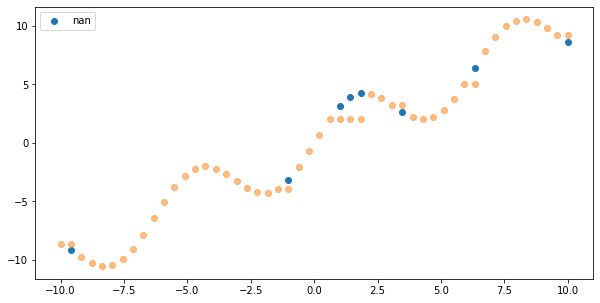

In [111]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_pad_fillna'], alpha=0.5)
plt.legend();

In [112]:
np.mean(np.abs(df['true_y'] - df['y_pad_fillna']))

0.1797343233478001

In [113]:
df['y_bfill'] = df['y']
df['y_bfill'] = df['y_bfill'].fillna(method="bfill")
df.head()

,x,true_y,y,y_lin,y_pad,y_pad_fillna,y_bfill
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947,-9.780612
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


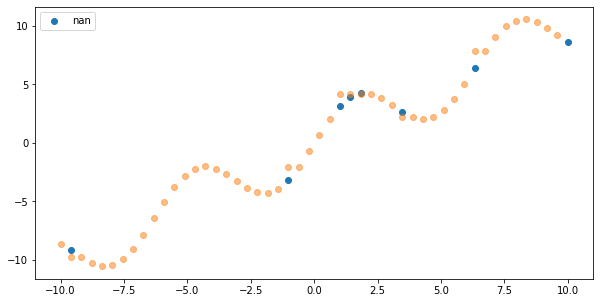

In [114]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_bfill'], alpha=0.5)
plt.legend();

In [115]:
np.mean(np.abs(df['true_y'] - df['y_bfill']))

0.10112029186156916

### nearest

In [116]:
df['y_nearest'] = df['y'].interpolate(method='nearest')
df.head()

,x,true_y,y,y_lin,y_pad,y_pad_fillna,y_bfill,y_nearest
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947,-9.780612,-8.639947
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


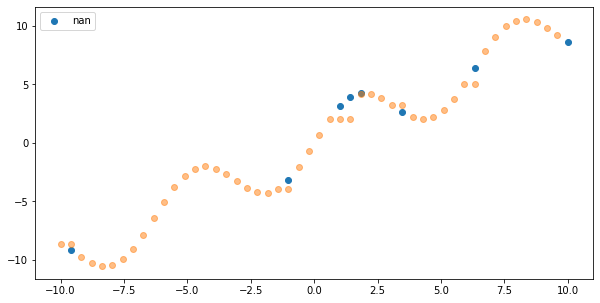

In [117]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_nearest'], alpha=0.5)
plt.legend();

In [118]:
np.mean(np.abs(df['true_y'] - df['y_nearest']))

0.12860154332846715

### polynomial

In [124]:
df['y_poly'] = df['y'].interpolate(method='polynomial', order=2)
df.head()

,x,true_y,y,y_lin,y_pad,y_pad_fillna,y_bfill,y_nearest,y_poly
0,-10.000000,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947,-8.639947
1,-9.591837,-9.176130,NaN,-9.210279,-8.639947,-8.639947,-9.780612,-8.639947,-9.221393
2,-9.183673,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612,-9.780612
3,-8.775510,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018,-10.287018
4,-8.367347,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089,-10.545089


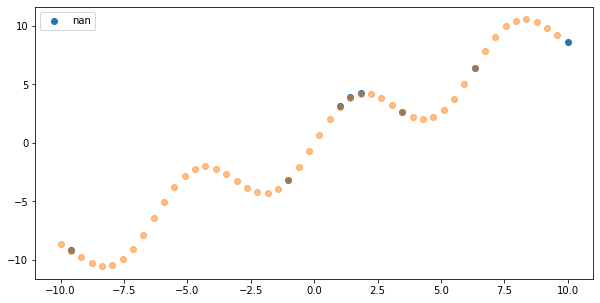

In [125]:
plt.figure(figsize=(10, 5))
plt.scatter(nan_x, nan_y, label='nan')
plt.scatter(df['x'], df['y_poly'], alpha=0.5)
plt.legend();

In [126]:
np.mean(np.abs(df['true_y'] - df['y_poly']))

0.004505216798914928

# Что сегодня узнали:
- Как работать с пропусками через **Pandas**
- Как удалять данные с пропусками через **dropna**
- Как заполнять NaN на среднее/медиану/моду/константу
- Как помечать пропуски через **новые признаки**
- Как заполнять пропуски через **группировки**
- Как **интерполировать** данные
    - Линейная
    - Предыдущее/Следующее/Ближайшее значение
    - Полиномиальная

**Муррр** ♥